In [1]:
!pip install playwright pandas python-dateutil
!playwright install chromium

In [8]:
aio(page.get_by_role("tab", name=__import__("re").compile("rese", __import__("re").I)).count())

TargetClosedError: Locator.count: Target page, context or browser has been closed

In [21]:
import requests
import pandas as pd
import time


API_KEY = "5fb878da1c1e945ba2ce9ae53ed287312e3c5c0365e7386eb8c928c2c9c314f0"


DATA_ID = "0x95bcc98cbc53cddf:0x728ecd3e472e1301"   

def traer_reviews(api_key, data_id, max_paginas, sort="newestFirst"):
    """
    Trae reseñas de Google Maps vía SerpApi.
    max_paginas: cada página = 1 búsqueda de tus 250. Página 1 trae 8; las siguientes hasta 20.
    """
    url = "https://serpapi.com/search"
    params = {
        "engine": "google_maps_reviews",
        "data_id": data_id,
        "hl": "es",
        "sort_by": sort,
        "api_key": api_key,
    }

    todas, lugar, busquedas = [], None, 0
    for pagina in range(max_paginas):
        r = requests.get(url, params=params, timeout=60)
        data = r.json()
        busquedas += 1

        if data.get("search_metadata", {}).get("status") == "Error" or "error" in data:
            print(f"⚠️ Error de SerpApi: {data.get('error', 'desconocido')}")
            break

        if lugar is None:
            lugar = data.get("place_info", {})
            if lugar:
                print(f"📍 {lugar.get('title')} | Total de reseñas en Google: {lugar.get('reviews')}")

        nuevas = data.get("reviews", [])
        todas.extend(nuevas)
        print(f"   Página {pagina+1}: +{len(nuevas)} reseñas  (acumulado: {len(todas)})")

        token = data.get("serpapi_pagination", {}).get("next_page_token")
        if not token:
            print("✅ No hay más páginas: llegamos al final de las reseñas.")
            break

        params = {
            "engine": "google_maps_reviews",
            "data_id": data_id,
            "hl": "es",
            "next_page_token": token,
            "num": 20,
            "api_key": api_key,
        }
        time.sleep(1)

    print(f"\n🔎 Búsquedas usadas en esta corrida: {busquedas} (de tus 250 mensuales)")
    return todas, lugar


reviews, lugar = traer_reviews(API_KEY, DATA_ID, max_paginas=1)
print(f"\nTotal traído: {len(reviews)}")
if reviews:
    print("\n─── Ejemplo de la primera reseña ───")
    print("Autor:", reviews[0].get("user", {}).get("name"))
    print("Fecha:", reviews[0].get("iso_date"))
    print("Texto:", (reviews[0].get("extracted_snippet") or {}).get("original") or reviews[0].get("snippet"))

📍 Hospital General de Agudos Dr. Teodoro Álvarez | Total de reseñas en Google: 1416
   Página 1: +8 reseñas  (acumulado: 8)

🔎 Búsquedas usadas en esta corrida: 1 (de tus 250 mensuales)

Total traído: 8

─── Ejemplo de la primera reseña ───
Autor: belu terra
Fecha: 2026-06-30T04:46:21Z
Texto: El mejor hospital !!


In [22]:
def a_tabla(reviews):
    filas = []
    for rv in reviews:
        u = rv.get("user", {})
        texto = (rv.get("extracted_snippet") or {}).get("original") or rv.get("snippet")
        resp = rv.get("response") or {}
        resp_texto = (resp.get("extracted_snippet") or {}).get("original") or resp.get("snippet")
        filas.append({
            "autor": u.get("name"),
            "es_local_guide": u.get("local_guide"),
            "rating": rv.get("rating"),
            "fecha_relativa": rv.get("date"),
            "fecha_iso": rv.get("iso_date"),
            "fuente": rv.get("source"),
            "texto": texto,
            "respuesta_negocio": resp_texto,
        })
    df = pd.DataFrame(filas)
    con_texto = df[df["texto"].notna() & (df["texto"].astype(str).str.strip() != "")]
    return con_texto

In [23]:
reviews, lugar = traer_reviews(API_KEY, DATA_ID, max_paginas=80)

df = a_tabla(reviews)
print(f"\n✅ Reseñas con texto: {len(df)} de {len(reviews)} traídas")
df.to_csv("reviews_alvarez.csv", index=False, encoding="utf-8-sig")
df.head(10)

📍 Hospital General de Agudos Dr. Teodoro Álvarez | Total de reseñas en Google: 1416
   Página 1: +8 reseñas  (acumulado: 8)
   Página 2: +20 reseñas  (acumulado: 28)
   Página 3: +20 reseñas  (acumulado: 48)
   Página 4: +20 reseñas  (acumulado: 68)
   Página 5: +20 reseñas  (acumulado: 88)
   Página 6: +20 reseñas  (acumulado: 108)
   Página 7: +20 reseñas  (acumulado: 128)
   Página 8: +20 reseñas  (acumulado: 148)
   Página 9: +19 reseñas  (acumulado: 167)
   Página 10: +20 reseñas  (acumulado: 187)
   Página 11: +20 reseñas  (acumulado: 207)
   Página 12: +19 reseñas  (acumulado: 226)
   Página 13: +20 reseñas  (acumulado: 246)
   Página 14: +20 reseñas  (acumulado: 266)
   Página 15: +20 reseñas  (acumulado: 286)
   Página 16: +20 reseñas  (acumulado: 306)
   Página 17: +19 reseñas  (acumulado: 325)
   Página 18: +20 reseñas  (acumulado: 345)
   Página 19: +20 reseñas  (acumulado: 365)
   Página 20: +20 reseñas  (acumulado: 385)
   Página 21: +20 reseñas  (acumulado: 405)
   Págin

,autor,es_local_guide,rating,fecha_relativa,fecha_iso,fuente,texto,respuesta_negocio
0,belu terra,True,5.0,Hace 1 día,2026-06-30T04:46:21Z,Google,El mejor hospital !!,None
1,Kalindi45,True,1.0,Hace 6 días,2026-06-26T00:13:40Z,Google,Un desastre la GUARDIA DE TRAUMATOLOGIA. Malt...,None
2,roman ocampo,True,3.0,una semana atrás,2026-06-24T04:37:36Z,Google,Con el frío que hace hoy 24 de junio de 2026 e...,None
4,Laboratorio HyS,True,5.0,una semana atrás,2026-06-23T15:50:36Z,Google,Las estrellas son para los camilleros que nos ...,None
5,angelica paz,True,1.0,una semana atrás,2026-06-20T14:31:48Z,Google,"No se le puede dar 0 estrellas, una porquería ...",None
7,Carla De Natale,True,5.0,Editado 2 semanas atrás,2025-10-20T23:53:31Z,Google,Excelente el servicio de dermatología y destac...,None
8,Mica Ela,None,1.0,Hace 4 semanas,2026-06-03T13:40:50Z,Google,Me operaron de Endometriosis hace un tiempo y ...,None
9,Matias Saslavsky,None,5.0,Hace un mes,2026-05-27T18:22:42Z,Google,He estado haciendo tratamiento psicológico y p...,None
10,Mabel Flores,None,5.0,Hace 8 meses,2025-10-28T17:36:28Z,Google,El hospital lo veo más limpio que otras veces....,None
11,Johanna Deborah Moyano,None,5.0,Hace 5 meses,2026-01-21T22:59:29Z,Google,"Muy agradecida con el Dr. Damián Levy, es el m...",None


In [24]:
DATA_ID_PENNA = "0x95bccb0b97abc14b:0xaa2126332903d16f"   

reviews_penna, lugar_penna = traer_reviews(API_KEY, DATA_ID_PENNA, max_paginas=1)
print(f"\nTotal traído: {len(reviews_penna)}")
if reviews_penna:
    print("\n─── Ejemplo de la primera reseña ───")
    print("Autor:", reviews_penna[0].get("user", {}).get("name"))
    print("Fecha:", reviews_penna[0].get("iso_date"))
    print("Texto:", (reviews_penna[0].get("extracted_snippet") or {}).get("original") or reviews_penna[0].get("snippet"))

📍 Hospital General de Agudos José María Penna | Total de reseñas en Google: 784
   Página 1: +8 reseñas  (acumulado: 8)

🔎 Búsquedas usadas en esta corrida: 1 (de tus 250 mensuales)

Total traído: 8

─── Ejemplo de la primera reseña ───
Autor: Marcela silvina Callan
Fecha: 2026-06-25T19:26:44Z
Texto: Excelente hospital y atención de los médicos 👏 me opero la doctora Gisela castro Excelente profesional y todo su equipo 👏. Muchas gracias 😘 y pronto me opera el doctor Carlos bao especialista en cadera y traumatologia .Excelente servicio muchas gracias 😘 AMO 💕 EL HOSPITAL PENNA .


In [25]:
reviews_penna, lugar_penna = traer_reviews(API_KEY, DATA_ID_PENNA, max_paginas=80)

df_penna = a_tabla(reviews_penna)
print(f"\n✅ Reseñas con texto: {len(df_penna)} de {len(reviews_penna)} traídas")
df_penna.to_csv("reviews_penna.csv", index=False, encoding="utf-8-sig")
df_penna.head(10)

📍 Hospital General de Agudos José María Penna | Total de reseñas en Google: 784
   Página 1: +8 reseñas  (acumulado: 8)
   Página 2: +20 reseñas  (acumulado: 28)
   Página 3: +19 reseñas  (acumulado: 47)
   Página 4: +19 reseñas  (acumulado: 66)
   Página 5: +20 reseñas  (acumulado: 86)
   Página 6: +19 reseñas  (acumulado: 105)
   Página 7: +20 reseñas  (acumulado: 125)
   Página 8: +20 reseñas  (acumulado: 145)
   Página 9: +20 reseñas  (acumulado: 165)
   Página 10: +20 reseñas  (acumulado: 185)
   Página 11: +20 reseñas  (acumulado: 205)
   Página 12: +20 reseñas  (acumulado: 225)
   Página 13: +20 reseñas  (acumulado: 245)
   Página 14: +20 reseñas  (acumulado: 265)
   Página 15: +20 reseñas  (acumulado: 285)
   Página 16: +20 reseñas  (acumulado: 305)
   Página 17: +19 reseñas  (acumulado: 324)
   Página 18: +20 reseñas  (acumulado: 344)
   Página 19: +20 reseñas  (acumulado: 364)
   Página 20: +19 reseñas  (acumulado: 383)
   Página 21: +20 reseñas  (acumulado: 403)
   Página 22

,autor,es_local_guide,rating,fecha_relativa,fecha_iso,fuente,texto,respuesta_negocio
0,Marcela silvina Callan,True,5.0,Hace 6 días,2026-06-25T19:26:44Z,Google,Excelente hospital y atención de los médicos 👏...,None
2,Juan Navarro,True,1.0,una semana atrás,2026-06-22T22:29:51Z,Google,Buenas tardes\nAlguien sabe a que hora dan tur...,None
3,Federico Amaya,True,4.0,una semana atrás,2026-06-22T12:14:44Z,Google,"Hoy me hice una practica de laboratorio y, la ...",None
4,Francisco José Flores,True,4.0,Editado 2 semanas atrás,2022-01-29T02:07:14Z,Google,"Muy buen hospital, ha mejorado muchisimo y se...",None
6,Alicia Ortega Vazquez,True,5.0,2 semanas atrás,2026-06-13T01:36:19Z,Google,El hospital penna es un hospital desbordado de...,None
7,Sergio Luna,True,5.0,Editado 3 semanas atrás,2026-01-18T15:09:05Z,Google,"Quiero destacar que la atención es perfecta, d...",None
8,Evelina Elena Pereira,None,1.0,Hace 2 meses,2026-04-28T16:45:06Z,Google,Mi hija hace dos semanas saco turno por el 147...,None
9,Sergio Luna,None,5.0,Fecha de edición: Hace 3 semanas,2026-01-18T15:09:05Z,Google,"Quiero destacar que la atención es perfecta, d...",None
10,Yesica Rodriguez,None,1.0,Hace 8 meses,2025-10-07T03:27:55Z,Google,"Fui con un turno programado, llegué antes de h...",None
11,maria delos angeles vitetta,None,1.0,Hace 5 meses,2026-01-23T12:58:45Z,Google,Un desastre tenía un turno programado de hace ...,None


In [26]:
DATA_ID_DURAND = "0x95bcca6b0c5fce23:0x24eaa149c5e25cde"   


reviews_durand, lugar_durand = traer_reviews(API_KEY, DATA_ID_DURAND, max_paginas=1)
print(f"\nTotal traído: {len(reviews_durand)}")
if reviews_durand:
    print("\n─── Ejemplo de la primera reseña ───")
    print("Autor:", reviews_durand[0].get("user", {}).get("name"))
    print("Fecha:", reviews_durand[0].get("iso_date"))
    print("Texto:", (reviews_durand[0].get("extracted_snippet") or {}).get("original") or reviews_durand[0].get("snippet"))

📍 Hospital General de Agudos Carlos G. Durand | Total de reseñas en Google: 1800
   Página 1: +8 reseñas  (acumulado: 8)

🔎 Búsquedas usadas en esta corrida: 1 (de tus 250 mensuales)

Total traído: 8

─── Ejemplo de la primera reseña ───
Autor: Candelaria Schmid
Fecha: 2026-06-28T13:05:33Z
Texto: Una vergüenza, vas a la guardia enfermx y te hacen caminar una cuadra por la calle bordeando el edificio hasta la otra “guardia” que supuestamente te corresponde para que llegues a una carpa en el medio del estacionamiento al aire libre y el de la garita del estacionamiento te diga que no abre hasta dentro de una hora cuando la recepcionista de la guardia original te tomó los datos y te mandó para allá y son un hospital con guardia 24hs… está el de la garita del estacionamiento pero no los médicos? Cualquiera! Nadie sabe nada, te manosean, te desinforman y no te atienden.


In [27]:
reviews_durand, lugar_durand = traer_reviews(API_KEY, DATA_ID_DURAND, max_paginas=80)

df_durand = a_tabla(reviews_durand)
print(f"\n✅ Reseñas con texto: {len(df_durand)} de {len(reviews_durand)} traídas")
df_durand.to_csv("reviews_durand.csv", index=False, encoding="utf-8-sig")
df_durand.head(10)

📍 Hospital General de Agudos Carlos G. Durand | Total de reseñas en Google: 1800
   Página 1: +8 reseñas  (acumulado: 8)
   Página 2: +20 reseñas  (acumulado: 28)
   Página 3: +20 reseñas  (acumulado: 48)
   Página 4: +20 reseñas  (acumulado: 68)
   Página 5: +20 reseñas  (acumulado: 88)
   Página 6: +20 reseñas  (acumulado: 108)
   Página 7: +20 reseñas  (acumulado: 128)
   Página 8: +20 reseñas  (acumulado: 148)
   Página 9: +20 reseñas  (acumulado: 168)
   Página 10: +20 reseñas  (acumulado: 188)
   Página 11: +20 reseñas  (acumulado: 208)
   Página 12: +20 reseñas  (acumulado: 228)
   Página 13: +20 reseñas  (acumulado: 248)
   Página 14: +19 reseñas  (acumulado: 267)
   Página 15: +20 reseñas  (acumulado: 287)
   Página 16: +20 reseñas  (acumulado: 307)
   Página 17: +19 reseñas  (acumulado: 326)
   Página 18: +20 reseñas  (acumulado: 346)
   Página 19: +20 reseñas  (acumulado: 366)
   Página 20: +19 reseñas  (acumulado: 385)
   Página 21: +20 reseñas  (acumulado: 405)
   Página 2

,autor,es_local_guide,rating,fecha_relativa,fecha_iso,fuente,texto,respuesta_negocio
0,Candelaria Schmid,True,1.0,Hace 3 días,2026-06-28T13:05:33Z,Google,"Una vergüenza, vas a la guardia enfermx y te h...",None
1,sofia vazquez,True,1.0,Hace 4 días,2026-06-27T21:32:28Z,Google,No se atiendan con STASI ISABEL NOEMÍ. Fui a l...,None
2,Gustavo Rubio,True,1.0,una semana atrás,2026-06-24T22:59:30Z,Google,Urologia t internan para al dia siguiente oper...,None
3,Daniel López,True,5.0,una semana atrás,2026-06-23T17:33:59Z,Google,El vacunartorio es impecable las dos personas ...,None
4,Martin Rendell,True,5.0,una semana atrás,2026-06-22T19:43:22Z,Google,Pregunta realizan pruebas de adn,None
5,Adriana Alí,True,1.0,una semana atrás,2026-06-22T14:41:38Z,Google,Mi marido fue para ver a un traumatologo. Con ...,None
6,Alina Karina Mariette,True,5.0,2 semanas atrás,2026-06-16T20:46:26Z,Google,En mí caso particular la atención que recibí d...,None
8,Mariangela Gomez,None,1.0,Hace un mes,2026-05-20T17:52:13Z,Google,Vine a traer a mi madre que tiene 73 años y te...,None
9,7887zz,None,1.0,Hace 4 meses,2026-02-26T22:26:26Z,Google,En OFTALMOLOGIA los médicos de planta se ausen...,None
10,Alina Karina Mariette,None,5.0,Hace 2 semanas,2026-06-16T20:46:26Z,Google,En mí caso particular la atención que recibí d...,None


In [29]:
df["hospital"] = "Alvarez"

cols = ["hospital"] + [c for c in df.columns if c != "hospital"]
df = df[cols]

df.to_csv("reviews_alvarez.csv", index=False, encoding="utf-8-sig")
df.head()

,hospital,autor,es_local_guide,rating,fecha_relativa,fecha_iso,fuente,texto,respuesta_negocio
0,Alvarez,belu terra,True,5.0,Hace 1 día,2026-06-30T04:46:21Z,Google,El mejor hospital !!,None
1,Alvarez,Kalindi45,True,1.0,Hace 6 días,2026-06-26T00:13:40Z,Google,Un desastre la GUARDIA DE TRAUMATOLOGIA. Malt...,None
2,Alvarez,roman ocampo,True,3.0,una semana atrás,2026-06-24T04:37:36Z,Google,Con el frío que hace hoy 24 de junio de 2026 e...,None
4,Alvarez,Laboratorio HyS,True,5.0,una semana atrás,2026-06-23T15:50:36Z,Google,Las estrellas son para los camilleros que nos ...,None
5,Alvarez,angelica paz,True,1.0,una semana atrás,2026-06-20T14:31:48Z,Google,"No se le puede dar 0 estrellas, una porquería ...",None


In [30]:
df_penna["hospital"] = "Penna"
df_penna.to_csv("reviews_penna.csv", index=False, encoding="utf-8-sig")

df_durand["hospital"] = "Durand"
df_durand.to_csv("reviews_durand.csv", index=False, encoding="utf-8-sig")

In [31]:
for d, nombre in [(df_penna, "reviews_penna.csv"), (df_durand, "reviews_durand.csv")]:
    cols = ["hospital"] + [c for c in d.columns if c != "hospital"]
    d = d[cols]
    d.to_csv(nombre, index=False, encoding="utf-8-sig")
    print(f"{nombre}: {list(d.columns)}")

reviews_penna.csv: ['hospital', 'autor', 'es_local_guide', 'rating', 'fecha_relativa', 'fecha_iso', 'fuente', 'texto', 'respuesta_negocio']
reviews_durand.csv: ['hospital', 'autor', 'es_local_guide', 'rating', 'fecha_relativa', 'fecha_iso', 'fuente', 'texto', 'respuesta_negocio']


In [32]:
df_todos = pd.concat([df, df_penna, df_durand], ignore_index=True)

df_todos.to_csv("reviews_todos.csv", index=False, encoding="utf-8-sig")
print(f"Total de reseñas combinadas: {len(df_todos)}")
print(df_todos["hospital"].value_counts())   
df_todos.head()

Total de reseñas combinadas: 2812
hospital
Durand     1287
Alvarez     981
Penna       544
Name: count, dtype: int64


,hospital,autor,es_local_guide,rating,fecha_relativa,fecha_iso,fuente,texto,respuesta_negocio
0,Alvarez,belu terra,True,5.0,Hace 1 día,2026-06-30T04:46:21Z,Google,El mejor hospital !!,None
1,Alvarez,Kalindi45,True,1.0,Hace 6 días,2026-06-26T00:13:40Z,Google,Un desastre la GUARDIA DE TRAUMATOLOGIA. Malt...,None
2,Alvarez,roman ocampo,True,3.0,una semana atrás,2026-06-24T04:37:36Z,Google,Con el frío que hace hoy 24 de junio de 2026 e...,None
3,Alvarez,Laboratorio HyS,True,5.0,una semana atrás,2026-06-23T15:50:36Z,Google,Las estrellas son para los camilleros que nos ...,None
4,Alvarez,angelica paz,True,1.0,una semana atrás,2026-06-20T14:31:48Z,Google,"No se le puede dar 0 estrellas, una porquería ...",None


In [33]:
df = pd.read_csv("reviews_todos.csv")

conteo = df["rating"].value_counts().sort_index()         
porcentaje = df["rating"].value_counts(normalize=True).sort_index() * 100  

tabla = pd.DataFrame({
    "cantidad": conteo,
    "porcentaje": porcentaje.round(1)
})
tabla.index.name = "rating"

print(f"Total de reseñas: {len(df)}")
print(f"Reseñas con rating: {df['rating'].notna().sum()}\n")
print(tabla)

Total de reseñas: 2812
Reseñas con rating: 2812

        cantidad  porcentaje
rating                      
1.0          984        35.0
2.0          126         4.5
3.0          201         7.1
4.0          321        11.4
5.0         1180        42.0


In [34]:
#Here we see that 77% of the reviews are distributed between the best and the worst rating

In [37]:
import requests
import pandas as pd
import time


API_KEY = "..."

DATA_ID_ARGERICH = "0x95a334c9514879fd:0x8a4aa20a8c0e2145"  

def traer_reviews(api_key, data_id, max_paginas, sort="newestFirst"):
    url = "https://serpapi.com/search"
    params = {
        "engine": "google_maps_reviews",
        "data_id": data_id,
        "hl": "es",
        "sort_by": sort,
        "api_key": api_key,
    }
    todas, lugar, busquedas = [], None, 0
    for pagina in range(max_paginas):
        r = requests.get(url, params=params, timeout=60)
        data = r.json()
        busquedas += 1
        if data.get("search_metadata", {}).get("status") == "Error" or "error" in data:
            print(f"⚠️ Error de SerpApi: {data.get('error', 'desconocido')}")
            break
        if lugar is None:
            lugar = data.get("place_info", {})
            if lugar:
                print(f"📍 {lugar.get('title')} | Total de reseñas en Google: {lugar.get('reviews')}")
        nuevas = data.get("reviews", [])
        todas.extend(nuevas)
        print(f"   Página {pagina+1}: +{len(nuevas)} reseñas  (acumulado: {len(todas)})")
        token = data.get("serpapi_pagination", {}).get("next_page_token")
        if not token:
            print("✅ No hay más páginas: llegamos al final.")
            break
        params = {
            "engine": "google_maps_reviews",
            "data_id": data_id,
            "hl": "es",
            "next_page_token": token,
            "num": 20,
            "api_key": api_key,
        }
        time.sleep(1)
    print(f"\n🔎 Búsquedas usadas: {busquedas} (de tus 250 mensuales)")
    return todas, lugar

def a_tabla(reviews, hospital=None):
    filas = []
    for rv in reviews:
        u = rv.get("user", {})
        texto = (rv.get("extracted_snippet") or {}).get("original") or rv.get("snippet")
        resp = rv.get("response") or {}
        resp_texto = (resp.get("extracted_snippet") or {}).get("original") or resp.get("snippet")
        filas.append({
            "hospital": hospital,
            "autor": u.get("name"),
            "es_local_guide": u.get("local_guide"),
            "rating": rv.get("rating"),
            "fecha_relativa": rv.get("date"),
            "fecha_iso": rv.get("iso_date"),
            "fuente": rv.get("source"),
            "texto": texto,
            "respuesta_negocio": resp_texto,
        })
    df = pd.DataFrame(filas)
    return df[df["texto"].notna() & (df["texto"].astype(str).str.strip() != "")]

In [38]:
reviews_argerich, lugar_argerich = traer_reviews(API_KEY, DATA_ID_ARGERICH, max_paginas=1)
print(f"\nTotal traído: {len(reviews_argerich)}")
if reviews_argerich:
    print("\n─── Ejemplo de la primera reseña ───")
    print("Autor:", reviews_argerich[0].get("user", {}).get("name"))
    print("Fecha:", reviews_argerich[0].get("iso_date"))
    print("Texto:", (reviews_argerich[0].get("extracted_snippet") or {}).get("original") or reviews_argerich[0].get("snippet"))

📍 Hospital General de Agudos Dr. Cosme Argerich | Total de reseñas en Google: 1390
   Página 1: +8 reseñas  (acumulado: 8)

🔎 Búsquedas usadas: 1 (de tus 250 mensuales)

Total traído: 8

─── Ejemplo de la primera reseña ───
Autor: LEGUIMNACUD S.R.L
Fecha: 2026-06-28T18:56:01Z
Texto: None


In [39]:
reviews_argerich, lugar_argerich = traer_reviews(API_KEY, DATA_ID_ARGERICH, max_paginas=80)

df_argerich = a_tabla(reviews_argerich, hospital="Argerich")
print(f"\n✅ Reseñas con texto: {len(df_argerich)} de {len(reviews_argerich)} traídas")
df_argerich.to_csv("reviews_argerich.csv", index=False, encoding="utf-8-sig")
df_argerich.head(10)

📍 Hospital General de Agudos Dr. Cosme Argerich | Total de reseñas en Google: 1390
   Página 1: +8 reseñas  (acumulado: 8)
   Página 2: +20 reseñas  (acumulado: 28)
   Página 3: +19 reseñas  (acumulado: 47)
   Página 4: +20 reseñas  (acumulado: 67)
   Página 5: +20 reseñas  (acumulado: 87)
   Página 6: +19 reseñas  (acumulado: 106)
   Página 7: +20 reseñas  (acumulado: 126)
   Página 8: +20 reseñas  (acumulado: 146)
   Página 9: +20 reseñas  (acumulado: 166)
   Página 10: +20 reseñas  (acumulado: 186)
   Página 11: +20 reseñas  (acumulado: 206)
   Página 12: +20 reseñas  (acumulado: 226)
   Página 13: +19 reseñas  (acumulado: 245)
   Página 14: +20 reseñas  (acumulado: 265)
   Página 15: +19 reseñas  (acumulado: 284)
   Página 16: +20 reseñas  (acumulado: 304)
   Página 17: +20 reseñas  (acumulado: 324)
   Página 18: +20 reseñas  (acumulado: 344)
   Página 19: +19 reseñas  (acumulado: 363)
   Página 20: +19 reseñas  (acumulado: 382)
   Página 21: +20 reseñas  (acumulado: 402)
   Página

,hospital,autor,es_local_guide,rating,fecha_relativa,fecha_iso,fuente,texto,respuesta_negocio
1,Argerich,Gustavo Adolfo Assali,True,5.0,Hace 5 días,2026-06-26T20:04:26Z,Google,La guardia trabaja a tope todo el día con todo...,None
2,Argerich,Leito Cordoba,True,1.0,Hace 6 días,2026-06-26T08:19:52Z,Google,Me toco venir dos veces en mi vida! Y siempre ...,None
3,Argerich,Gisela Nogueiras,True,5.0,una semana atrás,2026-06-24T00:55:12Z,Google,Quiero agradecer al Doctor Walter Esteban junt...,None
4,Argerich,Noelia Araca,True,1.0,una semana atrás,2026-06-22T15:01:08Z,Google,"Fui hace unos días a la UFU, tenía fiebre, dol...",None
5,Argerich,Ricardo Yebra,True,5.0,una semana atrás,2026-06-22T00:03:56Z,Google,Excelencia en todo. Ecodopler. Spect. Cardiolo...,None
7,Argerich,Daniel Fernandez,True,1.0,una semana atrás,2026-06-19T04:52:31Z,Google,Hospital argerich enfermeria un desastre lo de...,None
8,Argerich,Humbert Caray ph,None,1.0,Fecha de edición: Hace 2 meses,2025-10-15T19:03:49Z,Google,Impresionante que un país tan desarrollado ten...,None
9,Argerich,Tiara (is),None,3.0,Hace 2 semanas,2026-06-18T12:02:52Z,Google,"Médicos excelentes , pésima atención o más bie...",None
10,Argerich,Jesica Donnarumma,None,1.0,Hace 6 meses,2025-12-29T12:28:38Z,Google,Pésima atención. Tengo turno en Neumonología e...,None
11,Argerich,Joaquín Cettour,None,1.0,Hace 2 meses,2026-04-30T05:51:21Z,Google,No se queden esperando a que los atiendan si e...,None


In [40]:
DATA_ID_RIVADAVIA = "0x95bcca9dd8fe28b9:0x9d6f05272ae5ece8"   

reviews_rivadavia, lugar_rivadavia = traer_reviews(API_KEY, DATA_ID_RIVADAVIA, max_paginas=1)
print(f"\nTotal traído: {len(reviews_rivadavia)}")
if reviews_rivadavia:
    print("\n─── Ejemplo de la primera reseña ───")
    print("Autor:", reviews_rivadavia[0].get("user", {}).get("name"))
    print("Fecha:", reviews_rivadavia[0].get("iso_date"))
    print("Texto:", (reviews_rivadavia[0].get("extracted_snippet") or {}).get("original") or reviews_rivadavia[0].get("snippet"))

📍 Hospital General de Agudos Bernardino Rivadavia | Total de reseñas en Google: 1305
   Página 1: +8 reseñas  (acumulado: 8)

🔎 Búsquedas usadas: 1 (de tus 250 mensuales)

Total traído: 8

─── Ejemplo de la primera reseña ───
Autor: Gabriel Capeans
Fecha: 2026-07-01T01:52:58Z
Texto: Consulta, dan turno de otorrino o es por página? . Pregunto para ir .


In [41]:
reviews_rivadavia, lugar_rivadavia = traer_reviews(API_KEY, DATA_ID_RIVADAVIA, max_paginas=80)

df_rivadavia = a_tabla(reviews_rivadavia, hospital="Rivadavia")
print(f"\n✅ Reseñas con texto: {len(df_rivadavia)} de {len(reviews_rivadavia)} traídas")
df_rivadavia.to_csv("reviews_rivadavia.csv", index=False, encoding="utf-8-sig")
df_rivadavia.head(10)

📍 Hospital General de Agudos Bernardino Rivadavia | Total de reseñas en Google: 1305
   Página 1: +8 reseñas  (acumulado: 8)
   Página 2: +20 reseñas  (acumulado: 28)
   Página 3: +20 reseñas  (acumulado: 48)
   Página 4: +20 reseñas  (acumulado: 68)
   Página 5: +19 reseñas  (acumulado: 87)
   Página 6: +20 reseñas  (acumulado: 107)
   Página 7: +20 reseñas  (acumulado: 127)
   Página 8: +20 reseñas  (acumulado: 147)
   Página 9: +20 reseñas  (acumulado: 167)
   Página 10: +20 reseñas  (acumulado: 187)
   Página 11: +20 reseñas  (acumulado: 207)
   Página 12: +20 reseñas  (acumulado: 227)
   Página 13: +20 reseñas  (acumulado: 247)
   Página 14: +20 reseñas  (acumulado: 267)
   Página 15: +20 reseñas  (acumulado: 287)
   Página 16: +20 reseñas  (acumulado: 307)
   Página 17: +20 reseñas  (acumulado: 327)
   Página 18: +20 reseñas  (acumulado: 347)
   Página 19: +20 reseñas  (acumulado: 367)
   Página 20: +20 reseñas  (acumulado: 387)
   Página 21: +19 reseñas  (acumulado: 406)
   Pági

,hospital,autor,es_local_guide,rating,fecha_relativa,fecha_iso,fuente,texto,respuesta_negocio
0,Rivadavia,Gabriel Capeans,True,3.0,hace un día,2026-07-01T01:52:58Z,Google,"Consulta, dan turno de otorrino o es por págin...",None
1,Rivadavia,Alejandro Colombano,True,5.0,hace 2 días,2026-06-30T12:52:21Z,Google,Excelente,None
2,Rivadavia,Norka Durán,True,5.0,hace 6 días,2026-06-26T13:53:06Z,Google,Mí experiencia en la sección de Kinesiología f...,None
4,Rivadavia,flavio (Flavito),True,5.0,Hace una semana,2026-06-24T20:24:09Z,Google,Guardia. Atencion impecable. La doctora excele...,None
6,Rivadavia,Linda Medina López,True,1.0,Hace una semana,2026-06-19T13:47:47Z,Google,Mi hija fue 2 dias seguidos por un dolor agudo...,None
7,Rivadavia,Walter Amador,True,4.0,Hace una semana,2026-06-18T19:29:16Z,Google,Unica que fui por mi madre por un tema dermato...,None
8,Rivadavia,Patricia Irene Pla,None,4.0,Hace un mes,2026-05-22T03:15:20Z,Google,"Fui al Sector Odontología Dr Ramón Carrillo,co...",None
9,Rivadavia,Laura Postol,None,5.0,Hace un mes,2026-05-23T02:03:12Z,Google,Excelente ! Ayer fuí para atenderme con un esp...,None
10,Rivadavia,Lorena Josh,None,1.0,Hace 3 semanas,2026-06-05T04:39:51Z,Google,Mi mamá yendo más de 4 veces a la semana y nun...,None
11,Rivadavia,Leyvith Chaparro,None,5.0,Hace un mes,2026-05-04T16:21:18Z,Google,No encuentro palabras suficientes para agradec...,None


In [42]:
print(pd.read_csv("reviews_argerich.csv").columns.tolist())
print(pd.read_csv("reviews_rivadavia.csv").columns.tolist())

['hospital', 'autor', 'es_local_guide', 'rating', 'fecha_relativa', 'fecha_iso', 'fuente', 'texto', 'respuesta_negocio']
['hospital', 'autor', 'es_local_guide', 'rating', 'fecha_relativa', 'fecha_iso', 'fuente', 'texto', 'respuesta_negocio']


In [43]:
df_arg = pd.read_csv("reviews_argerich.csv")
df_arg["hospital"] = "Argerich"
df_arg = df_arg[["hospital"] + [c for c in df_arg.columns if c != "hospital"]] 
df_arg.to_csv("reviews_argerich.csv", index=False, encoding="utf-8-sig")

df_riv = pd.read_csv("reviews_rivadavia.csv")
df_riv["hospital"] = "Rivadavia"
df_riv = df_riv[["hospital"] + [c for c in df_riv.columns if c != "hospital"]]
df_riv.to_csv("reviews_rivadavia.csv", index=False, encoding="utf-8-sig")

print("Argerich:", df_arg.columns.tolist())
print("Rivadavia:", df_riv.columns.tolist())

Argerich: ['hospital', 'autor', 'es_local_guide', 'rating', 'fecha_relativa', 'fecha_iso', 'fuente', 'texto', 'respuesta_negocio']
Rivadavia: ['hospital', 'autor', 'es_local_guide', 'rating', 'fecha_relativa', 'fecha_iso', 'fuente', 'texto', 'respuesta_negocio']


In [44]:
todos = pd.read_csv("reviews_todos.csv")
arg = pd.read_csv("reviews_argerich.csv")
riv = pd.read_csv("reviews_rivadavia.csv")
print("Columnas de reviews_todos:", todos.columns.tolist())
print("¿Argerich tiene las mismas?:", set(arg.columns) == set(todos.columns))
print("¿Rivadavia tiene las mismas?:", set(riv.columns) == set(todos.columns))
ya_presentes = set(todos["hospital"].unique())
print("\nHospitales ya en reviews_todos:", ya_presentes)
a_sumar = []
if "Argerich" not in ya_presentes:
    a_sumar.append(arg)
else:
    print("⚠️ Argerich ya estaba: no lo sumo de nuevo.")
if "Rivadavia" not in ya_presentes:
    a_sumar.append(riv)
else:
    print("Rivadavia ya estaba: no lo sumo de nuevo.")
if a_sumar:
    a_sumar = [d[todos.columns] for d in a_sumar]   # mismo orden de columnas
    combinado = pd.concat([todos] + a_sumar, ignore_index=True)
else:
    combinado = todos
    print("Nada nuevo para sumar.")
combinado.to_csv("reviews_todos.csv", index=False, encoding="utf-8-sig")

print(f"\n✅ Total de reseñas ahora: {len(combinado)}")
print("\nReseñas por hospital:")
print(combinado["hospital"].value_counts())

Columnas de reviews_todos: ['hospital', 'autor', 'es_local_guide', 'rating', 'fecha_relativa', 'fecha_iso', 'fuente', 'texto', 'respuesta_negocio']
¿Argerich tiene las mismas?: True
¿Rivadavia tiene las mismas?: True

Hospitales ya en reviews_todos: {'Alvarez', 'Durand', 'Penna'}

✅ Total de reseñas ahora: 4355

Reseñas por hospital:
hospital
Durand       1287
Argerich     1000
Alvarez       981
Penna         544
Rivadavia     543
Name: count, dtype: int64


In [45]:
df = pd.read_csv("reviews_todos.csv")

conteo = df["rating"].value_counts().sort_index()          
porcentaje = df["rating"].value_counts(normalize=True).sort_index() * 100  # el %

tabla = pd.DataFrame({
    "cantidad": conteo,
    "porcentaje": porcentaje.round(1)
})
tabla.index.name = "rating"

print(f"Total de reseñas: {len(df)}")
print(f"Reseñas con rating: {df['rating'].notna().sum()}\n")
print(tabla)

Total de reseñas: 4355
Reseñas con rating: 4355

        cantidad  porcentaje
rating                      
1.0         1519        34.9
2.0          184         4.2
3.0          299         6.9
4.0          482        11.1
5.0         1871        43.0


In [47]:
df = pd.read_csv("reviews_todos.csv")

one_star = df[df["rating"] == 1.0].copy()

one_star["año"] = pd.to_datetime(one_star["fecha_iso"]).dt.year

por_año = one_star["año"].value_counts().sort_index()

print(f"Total de reseñas de 1 estrella: {len(one_star)}\n")
print("Reseñas de 1 estrella por año:")
print(por_año)

Total de reseñas de 1 estrella: 1519

Reseñas de 1 estrella por año:
año
2013      2
2014      1
2015      8
2016     27
2017     36
2018     51
2019     76
2020     48
2021    136
2022    252
2023    243
2024    234
2025    271
2026    134
Name: count, dtype: int64


In [49]:
df = pd.read_csv("reviews_todos.csv")

five_stars = df[df["rating"] == 5.0].copy()

five_stars["año"] = pd.to_datetime(five_stars["fecha_iso"]).dt.year

por_año = five_stars["año"].value_counts().sort_index()

print(f"Total de reseñas de 1 estrella: {len(five_stars)}\n")
print("Reseñas de 5 estrellas por año:")
print(por_año)

Total de reseñas de 1 estrella: 1871

Reseñas de 5 estrellas por año:
año
2012      3
2013     12
2014     13
2015     29
2016     48
2017     84
2018    101
2019    130
2020    147
2021    206
2022    281
2023    230
2024    214
2025    247
2026    126
Name: count, dtype: int64


In [50]:
una = one_star["año"].value_counts()
cinco = five_stars["año"].value_counts()

comparacion = pd.DataFrame({
    "1_estrella": una,
    "5_estrellas": cinco
}).fillna(0).astype(int).sort_index()

comparacion["diferencia"] = comparacion["1_estrella"] - comparacion["5_estrellas"]
comparacion["predominan"] = comparacion.apply(
    lambda r: "1 estrella" if r["1_estrella"] > r["5_estrellas"]
    else ("5 estrellas" if r["5_estrellas"] > r["1_estrella"] else "empate"),
    axis=1
)

print(comparacion)

      1_estrella  5_estrellas  diferencia   predominan
año                                                   
2012           0            3          -3  5 estrellas
2013           2           12         -10  5 estrellas
2014           1           13         -12  5 estrellas
2015           8           29         -21  5 estrellas
2016          27           48         -21  5 estrellas
2017          36           84         -48  5 estrellas
2018          51          101         -50  5 estrellas
2019          76          130         -54  5 estrellas
2020          48          147         -99  5 estrellas
2021         136          206         -70  5 estrellas
2022         252          281         -29  5 estrellas
2023         243          230          13   1 estrella
2024         234          214          20   1 estrella
2025         271          247          24   1 estrella
2026         134          126           8   1 estrella


In [69]:
comparacion.to_csv("comparacion_1vs5_por_anio.csv", encoding="utf-8-sig")

In [51]:
#Tendency was reverted in 2023
#Let' go to years 2023, 2024, 2025. What happened?

In [52]:
df = pd.read_csv("reviews_todos.csv")

df["anio"] = pd.to_datetime(df["fecha_iso"]).dt.year

df_filtrado = df[df["anio"].isin([2023, 2024, 2025])].copy()

df_filtrado.to_csv("reviews_2023_2025.csv", index=False, encoding="utf-8-sig")

print(f"Total original: {len(df)}")
print(f"Filtrado (2023-2025): {len(df_filtrado)}\n")
print("Reseñas por año:")
print(df_filtrado["anio"].value_counts().sort_index())
print("\nReseñas por hospital:")
print(df_filtrado["hospital"].value_counts())

Total original: 4355
Filtrado (2023-2025): 1743

Reseñas por año:
anio
2023    596
2024    533
2025    614
Name: count, dtype: int64

Reseñas por hospital:
hospital
Durand       501
Alvarez      383
Argerich     378
Rivadavia    246
Penna        235
Name: count, dtype: int64


In [53]:
df = pd.read_csv("reviews_2023_2025.csv")

conteo = df["rating"].value_counts().sort_index()
porcentaje = df["rating"].value_counts(normalize=True).sort_index() * 100

tabla = pd.DataFrame({
    "cantidad": conteo,
    "porcentaje": porcentaje.round(1)
})
tabla.index.name = "rating"

print(f"Total de reseñas (2023-2025): {len(df)}")
print(f"Reseñas con rating: {df['rating'].notna().sum()}\n")
print(tabla)

Total de reseñas (2023-2025): 1743
Reseñas con rating: 1743

        cantidad  porcentaje
rating                      
1.0          748        42.9
2.0           66         3.8
3.0           87         5.0
4.0          151         8.7
5.0          691        39.6


In [54]:
df = pd.read_csv("reviews_2023_2025.csv")
porcentaje = pd.crosstab(df["hospital"], df["rating"], normalize="index") * 100
print("Porcentaje de cada rating por hospital (%):")
print(porcentaje.round(1))

Porcentaje de cada rating por hospital (%):
rating      1.0  2.0  3.0  4.0   5.0
hospital                            
Alvarez    43.9  4.2  4.4  8.1  39.4
Argerich   43.1  3.2  4.0  9.8  39.9
Durand     38.1  4.6  5.2  9.8  42.3
Penna      53.2  4.7  6.8  6.4  28.9
Rivadavia  41.1  1.6  5.3  7.7  44.3


In [55]:
conteo = pd.crosstab(df["hospital"], df["rating"])
conteo["TOTAL"] = conteo.sum(axis=1)
print("\nCantidad de reseñas por hospital y rating:")
print(conteo)


Cantidad de reseñas por hospital y rating:
rating     1.0  2.0  3.0  4.0  5.0  TOTAL
hospital                                 
Alvarez    168   16   17   31  151    383
Argerich   163   12   15   37  151    378
Durand     191   23   26   49  212    501
Penna      125   11   16   15   68    235
Rivadavia  101    4   13   19  109    246


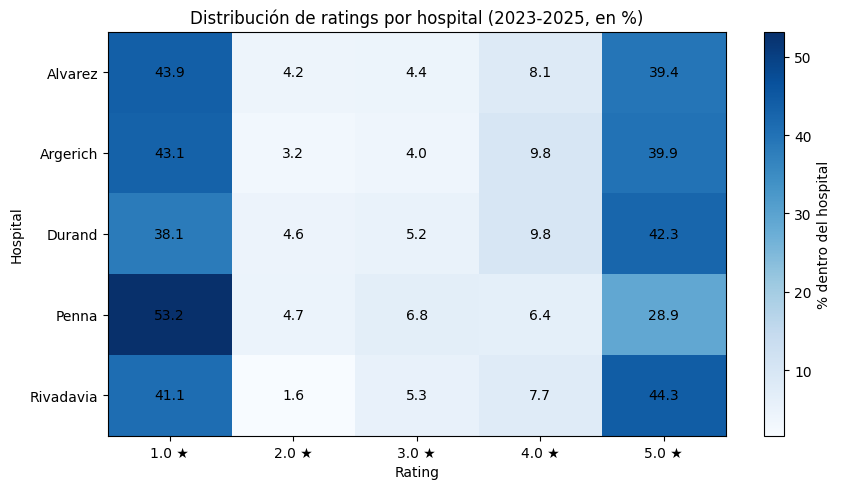

In [57]:
import matplotlib.pyplot as plt

df = pd.read_csv("reviews_2023_2025.csv")
porcentaje = pd.crosstab(df["hospital"], df["rating"], normalize="index") * 100

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(porcentaje.values, cmap="Blues", aspect="auto")  # un solo tono

ax.set_xticks(range(len(porcentaje.columns)))
ax.set_xticklabels([f"{c} ★" for c in porcentaje.columns])
ax.set_yticks(range(len(porcentaje.index)))
ax.set_yticklabels(porcentaje.index)
ax.set_xlabel("Rating")
ax.set_ylabel("Hospital")
ax.set_title("Distribución de ratings por hospital (2023-2025, en %)")

for i in range(len(porcentaje.index)):
    for j in range(len(porcentaje.columns)):
        ax.text(j, i, f"{porcentaje.values[i, j]:.1f}", ha="center", va="center",
                color="black", fontsize=10)

plt.colorbar(im, ax=ax, label="% dentro del hospital")
plt.tight_layout()
plt.show()

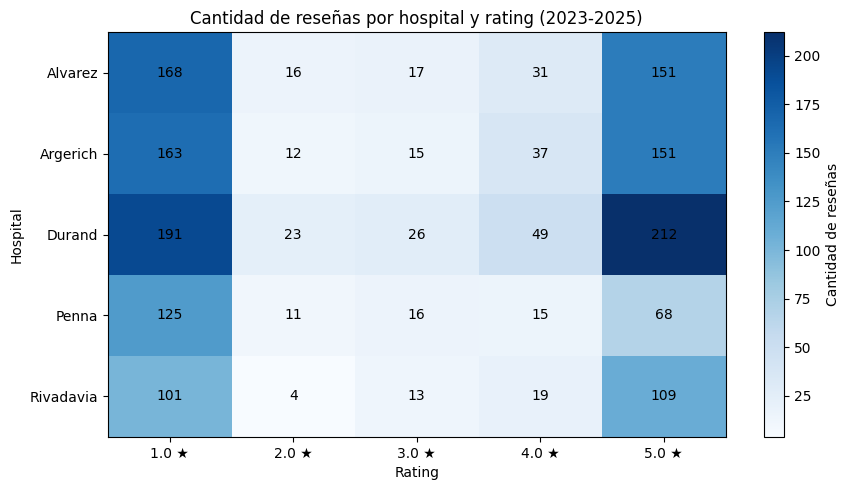

In [58]:
import matplotlib.pyplot as plt

df = pd.read_csv("reviews_2023_2025.csv")

conteo = pd.crosstab(df["hospital"], df["rating"])

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(conteo.values, cmap="Blues", aspect="auto")

ax.set_xticks(range(len(conteo.columns)))
ax.set_xticklabels([f"{c} ★" for c in conteo.columns])
ax.set_yticks(range(len(conteo.index)))
ax.set_yticklabels(conteo.index)
ax.set_xlabel("Rating")
ax.set_ylabel("Hospital")
ax.set_title("Cantidad de reseñas por hospital y rating (2023-2025)")

for i in range(len(conteo.index)):
    for j in range(len(conteo.columns)):
        ax.text(j, i, f"{conteo.values[i, j]:d}", ha="center", va="center",
                color="black", fontsize=10)

plt.colorbar(im, ax=ax, label="Cantidad de reseñas")
plt.tight_layout()
plt.show()

In [59]:
#Comparación 2022 vs 2023. Punto de quiebre

In [60]:
df = pd.read_csv("reviews_todos.csv") 
df["anio"] = pd.to_datetime(df["fecha_iso"]).dt.year
dos_anios = df[df["anio"].isin([2022, 2023])]
tabla = pd.crosstab([dos_anios["hospital"], dos_anios["anio"]], dos_anios["rating"])
print(tabla)

rating          1.0  2.0  3.0  4.0  5.0
hospital  anio                         
Alvarez   2022   53   12   12   28   65
          2023   53    5    8   15   55
Argerich  2022   46    5   15   21   73
          2023   47    8    5   17   47
Durand    2022   91    8   18   22   77
          2023   72    6    9   22   63
Penna     2022   28    3    8   11   25
          2023   35    4   10    4   27
Rivadavia 2022   34    5    7   10   41
          2023   36    1    3    6   38


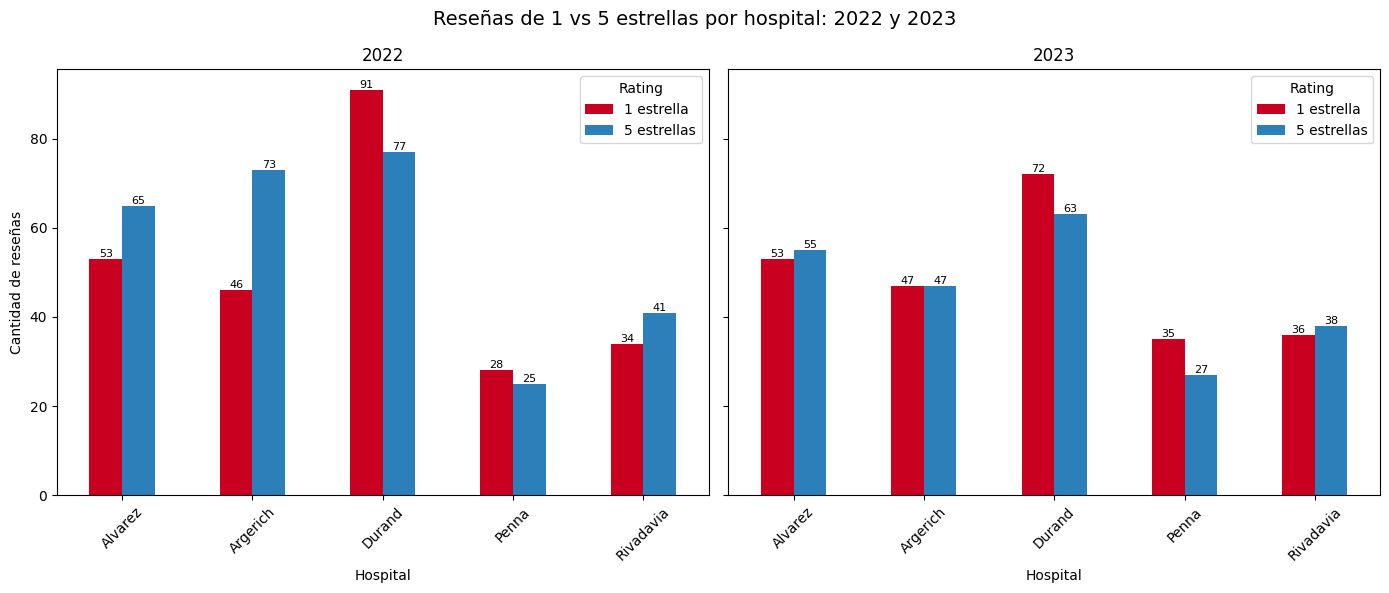

In [61]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("reviews_todos.csv")
df["anio"] = pd.to_datetime(df["fecha_iso"]).dt.year

sel = df[(df["rating"].isin([1.0, 5.0])) & (df["anio"].isin([2022, 2023]))]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, anio in zip(axes, [2022, 2023]):
    datos = sel[sel["anio"] == anio]
    tabla = pd.crosstab(datos["hospital"], datos["rating"])
    
    for r in [1.0, 5.0]:
        if r not in tabla.columns:
            tabla[r] = 0
    tabla = tabla[[1.0, 5.0]]
    tabla.columns = ["1 estrella", "5 estrellas"]

    tabla.plot(kind="bar", ax=ax, color=["#ca0020", "#2c7fb8"])
    ax.set_title(f"{anio}")
    ax.set_xlabel("Hospital")
    ax.set_ylabel("Cantidad de reseñas")
    ax.legend(title="Rating")
    ax.tick_params(axis="x", rotation=45)
    for c in ax.containers:
        ax.bar_label(c, fontsize=8)

fig.suptitle("Reseñas de 1 vs 5 estrellas por hospital: 2022 y 2023", fontsize=14)
plt.tight_layout()
plt.show()

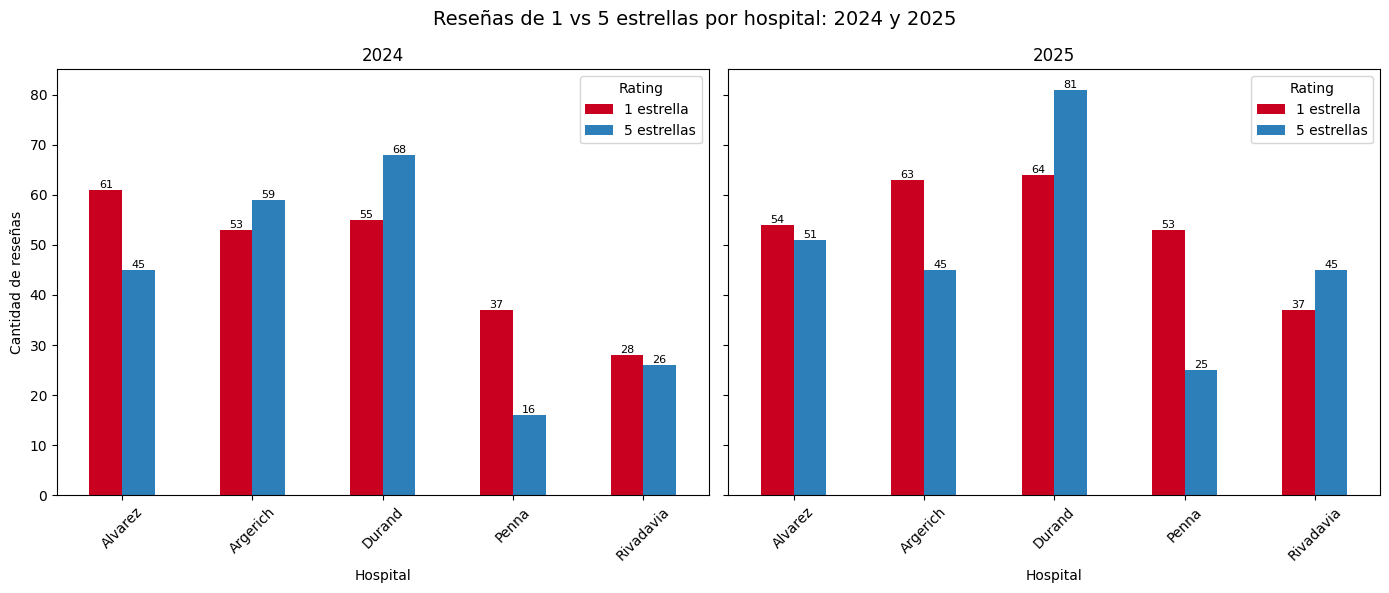

In [62]:
import matplotlib.pyplot as plt

df = pd.read_csv("reviews_todos.csv")
df["anio"] = pd.to_datetime(df["fecha_iso"]).dt.year

# Solo 1 y 5 estrellas, años 2024 y 2025
sel = df[(df["rating"].isin([1.0, 5.0])) & (df["anio"].isin([2024, 2025]))]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, anio in zip(axes, [2024, 2025]):
    datos = sel[sel["anio"] == anio]
    tabla = pd.crosstab(datos["hospital"], datos["rating"])
    for r in [1.0, 5.0]:
        if r not in tabla.columns:
            tabla[r] = 0
    tabla = tabla[[1.0, 5.0]]
    tabla.columns = ["1 estrella", "5 estrellas"]

    tabla.plot(kind="bar", ax=ax, color=["#ca0020", "#2c7fb8"])
    ax.set_title(f"{anio}")
    ax.set_xlabel("Hospital")
    ax.set_ylabel("Cantidad de reseñas")
    ax.legend(title="Rating")
    ax.tick_params(axis="x", rotation=45)
    for c in ax.containers:
        ax.bar_label(c, fontsize=8)

fig.suptitle("Reseñas de 1 vs 5 estrellas por hospital: 2024 y 2025", fontsize=14)
plt.tight_layout()
plt.show()

In [63]:
#Promedio estrellas

In [64]:
df = pd.read_csv("reviews_todos.csv")
df["anio"] = pd.to_datetime(df["fecha_iso"]).dt.year

promedio_general = df.groupby("anio")["rating"].agg(["mean", "count"]).round(2)
promedio_general.columns = ["rating_promedio", "cant_reviews"]
print("RATING PROMEDIO POR AÑO (todos los hospitales):")
print(promedio_general)

print("\n\nRATING PROMEDIO POR HOSPITAL Y AÑO:")
promedio_hosp = df.groupby(["hospital", "anio"])["rating"].mean().round(2)
tabla = promedio_hosp.unstack()
print(tabla.round(2))

RATING PROMEDIO POR AÑO (todos los hospitales):
      rating_promedio  cant_reviews
anio                               
2012             4.60             5
2013             3.91            23
2014             4.08            24
2015             3.80            51
2016             3.47           110
2017             3.67           184
2018             3.52           225
2019             3.50           277
2020             3.91           246
2021             3.38           450
2022             3.16           718
2023             3.02           596
2024             2.96           533
2025             2.96           614
2026             2.96           299


RATING PROMEDIO POR HOSPITAL Y AÑO:
anio       2012  2013  2014  2015  2016  2017  2018  2019  2020  2021  2022  \
hospital                                                                      
Alvarez     5.0  4.67  4.50  4.31  3.85  3.82  3.59  3.74  4.37  3.56  3.24   
Argerich    5.0  4.80  4.43  3.88  3.50  3.82  3.48  3.50  3.67  

In [65]:
import pandas as pd

df = pd.read_csv("reviews_todos.csv")
df["anio"] = pd.to_datetime(df["fecha_iso"]).dt.year

filtrado = df[(df["anio"].isin([2023, 2024, 2025])) & (df["rating"] == 1.0)].copy()

filtrado.to_csv("reviews_1estrella_2023_2025.csv", index=False, encoding="utf-8-sig")

print(f"Total de reseñas de 1 estrella (2023-2025): {len(filtrado)}\n")
print("Por hospital:")
print(filtrado["hospital"].value_counts())
print("\nPor año:")
print(filtrado["anio"].value_counts().sort_index())

Total de reseñas de 1 estrella (2023-2025): 748

Por hospital:
hospital
Durand       191
Alvarez      168
Argerich     163
Penna        125
Rivadavia    101
Name: count, dtype: int64

Por año:
anio
2023    243
2024    234
2025    271
Name: count, dtype: int64


In [66]:
completo = pd.read_csv("reviews_todos.csv")
completo["anio"] = pd.to_datetime(completo["fecha_iso"]).dt.year

completo_2025 = completo[completo["anio"] == 2025]

resumen = completo_2025.groupby("hospital")["rating"].agg(["mean", "count"]).round(2)
resumen.columns = ["promedio_estrellas", "cant_reviews"]

print(f"Total de reseñas de 2025: {len(completo_2025)}")
resumen

Total de reseñas de 2025: 614


,promedio_estrellas,cant_reviews
hospital,,
Alvarez,2.99,117
Argerich,2.76,125
Durand,3.22,180
Penna,2.45,94
Rivadavia,3.21,98


In [67]:
completo = pd.read_csv("reviews_todos.csv")
completo["anio"] = pd.to_datetime(completo["fecha_iso"]).dt.year

promedios = completo.groupby(["hospital", "anio"])["rating"].mean().round(2).unstack()

print("Promedio de estrellas por hospital y año:")
promedios

Promedio de estrellas por hospital y año:


anio,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
hospital,,,,,,,,,,,,,,,
Alvarez,5.0,4.67,4.50,4.31,3.85,3.82,3.59,3.74,4.37,3.56,3.24,3.10,2.75,2.99,2.92
Argerich,5.0,4.80,4.43,3.88,3.50,3.82,3.48,3.50,3.67,3.39,3.44,3.07,3.17,2.76,3.03
Durand,4.0,3.08,4.12,3.14,3.03,3.55,3.37,3.49,4.07,3.41,2.94,2.99,3.20,3.22,2.86
Penna,NaN,5.00,4.67,4.25,3.75,3.74,3.82,3.24,3.26,3.08,3.03,2.80,2.31,2.45,2.97
Rivadavia,NaN,5.00,2.75,3.75,3.42,3.39,3.38,3.21,3.74,3.23,3.20,3.11,3.02,3.21,3.12


In [68]:
completo = pd.read_csv("reviews_todos.csv")
completo["anio"] = pd.to_datetime(completo["fecha_iso"]).dt.year

resumen = completo.groupby("anio")["rating"].agg(["mean", "count"]).round(2)
resumen.columns = ["promedio_estrellas", "cant_reviews"]

resumen

,promedio_estrellas,cant_reviews
anio,,
2012,4.60,5
2013,3.91,23
2014,4.08,24
2015,3.80,51
2016,3.47,110
2017,3.67,184
2018,3.52,225
2019,3.50,277
2020,3.91,246
